In [1]:
import numpy as np
import matplotlib as mpl
#mpl.use('pdf')
import matplotlib.pyplot as plt
import numpy as np

# plt.rc('font', family='serif', serif='Times')
# Arial
plt.rc('font', family='Arial')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
plt.rc('axes', labelsize=11)
#axes.linewidth : 0.5
plt.rc('axes', linewidth=0.5)
#ytick.major.width : 0.5
plt.rc('ytick.major', width=0.5)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('ytick.minor', visible=True)

# set grid under the plot
# https://stackoverflow.com/questions/23357798/how-to-draw-grid-lines-behind-matplotlib-bar-graph
# https://stackoverflow.com/questions/1726391/matplotlib-draw-grid-lines-behind-other-graph-elements/39039520#39039520
plt.rc('axes', axisbelow=True)


#plt.style.use(r"..\..\styles\infocom.mplstyle") # Insert your save location here

# width as measured in inkscape
fig_width = 3.487
fig_height = fig_width / 1.618
# fig_height = 1.8
#fig_height = fig_width / 1.3 / 2

In [2]:
import numpy as np
num_instances = 6
# file_list = list(range(num_cases))
# filename_prefix = "results/results_japan_averaged_rate"
# folder_prefix = "results/TS8Module10-0708/"
folder_prefix = "results/TS8Module10-0716-8Ins/"
# folder_prefix = "results/TS8Module10-0711/"
acceptance_ratio = np.zeros((4, num_instances), dtype=float)
stored_keys = np.zeros((4, num_instances), dtype=float)
num_physical_hops = np.zeros((4, num_instances), dtype=float)
num_virtual_hops = np.zeros((4, num_instances), float)
num_qkd_module = np.zeros((4, num_instances), dtype=float)

case_prefix_list = ["results_module_No_OB_TR_german_averaged_rate", "results_module_OB_german_averaged_rate", 
         "results_module_TR_german_averaged_rate", "results_module_OB_TR_german_averaged_rate"]

In [3]:
average_key_rate_index = 4
for j in range(num_instances):
    #for file in file_list:
#     file = file_list[j]
    for i in range(len(case_prefix_list)):
        case_prefix = case_prefix_list[i]
        filename = folder_prefix + case_prefix + str(average_key_rate_index) + "_1.txt"
        with open(filename, "r") as f:
            lines = f.readlines()
            tmp = 100 * float(lines[0+2*j].split(" ")[0])
            acceptance_ratio[i][j] = tmp
            stored_keys[i][j] = float(lines[1+2*j].split(" ")[0])
            num_qkd_module[i][j] = float(lines[1+2*j].split(" ")[1])
            num_physical_hops[i][j] = float(lines[1+2*j].split(" ")[2])
            num_virtual_hops[i][j] = float(lines[1+2*j].split(" ")[3])
            
print(acceptance_ratio)
print(num_qkd_module)

[[18.28703704 19.3287037  19.3287037  19.3287037  19.3287037  19.3287037 ]
 [28.00925926 48.95833333 57.17592593 58.56481481 58.68055556 58.68055556]
 [24.65277778 35.30092593 42.70833333 49.76851852 55.78703704 62.26851852]
 [34.49074074 53.93518519 65.39351852 71.06481481 73.95833333 75.81018519]]
[[2.         2.         2.         2.         2.         2.        ]
 [2.         2.         2.         2.         2.         2.        ]
 [2.90467693 3.25267387 3.89117527 3.99170041 4.1639002  4.15987683]
 [1.80488125 2.18747323 2.47764252 2.65648429 2.76810497 2.84989021]]


In [4]:
dataMatrix = acceptance_ratio
print(dataMatrix)

[[18.28703704 19.3287037  19.3287037  19.3287037  19.3287037  19.3287037 ]
 [28.00925926 48.95833333 57.17592593 58.56481481 58.68055556 58.68055556]
 [24.65277778 35.30092593 42.70833333 49.76851852 55.78703704 62.26851852]
 [34.49074074 53.93518519 65.39351852 71.06481481 73.95833333 75.81018519]]


[0.1, 1.1, 2.1, 3.1, 4.1, 5.1]
['8', '10', '12', '14', '16', '18']


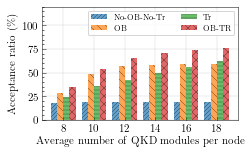

In [5]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances-1)

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['8', '10', '12', '14', '16', "18", "20"]
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
label_position = [elem + width/2 for elem in label_position]
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Acceptance ratio (\%)')
ax1.set_xlabel('Average number of QKD modules per node')
ax1.set_ylim(0, 120)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.17, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/module-acceptance-ratio.pdf')
fig.savefig('plot/module-acceptance-ratio.png')

In [6]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[2.         2.         2.         2.         2.         2.        ]
 [2.         2.         2.         2.         2.         2.        ]
 [2.90467693 3.25267387 3.89117527 3.99170041 4.1639002  4.15987683]
 [1.80488125 2.18747323 2.47764252 2.65648429 2.76810497 2.84989021]]


In [16]:
dataMatrix = stored_keys
print(dataMatrix)

[[ 245.6875      761.40625    1108.203125   1333.890625   1411.875
  1480.875     ]
 [  64.73109994  157.22214256  418.32928422  679.22053962  828.81898017
   904.00789941]
 [-197.59375    -115.1875      -23.609375    108.0625      134.328125
   164.609375  ]
 [-197.58405309 -136.46343825  -64.38230688   -4.78064946   72.91732633
   116.29574525]]


[0.1, 1.1, 2.1, 3.1, 4.1, 5.1]
['8', '10', '12', '14', '16', '18']


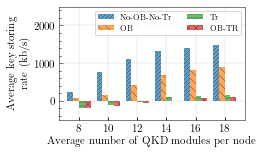

In [20]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances-1)

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['8', '10', '12', '14', '16', "18", "20"]
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
label_position = [elem + width/2 for elem in label_position]
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average key storing \n rate (kb/s)')
ax1.set_xlabel('Average number of QKD modules per node')
ax1.set_ylim(-500, 2500)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.21, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/module-key-storing-rate.pdf')
fig.savefig('plot/module-key-storing-rate.png')

In [9]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[2.         2.         2.         2.         2.         2.        ]
 [2.         2.         2.         2.         2.         2.        ]
 [2.90467693 3.25267387 3.89117527 3.99170041 4.1639002  4.15987683]
 [1.80488125 2.18747323 2.47764252 2.65648429 2.76810497 2.84989021]]


[0 1 2 3 4 5]
['8', '10', '12', '14', '16', '18']


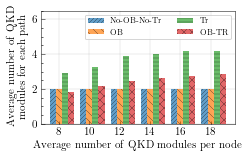

In [10]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances - 1)

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)

#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['8', '10', '12', '14', '16', "18", "20"]
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
label_position = [elem + width/2 for elem in label_position]
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of QKD \n modules for each path')
ax1.set_xlabel('Average number of QKD modules per node')
ax1.set_ylim(0, 6.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/module-num-qkd-modules.pdf')
fig.savefig('plot/module-num-qkd-modules.png')

In [11]:
dataMatrix = num_physical_hops
print(dataMatrix)

[[1.         1.         1.         1.         1.         1.        ]
 [1.         1.         1.         1.         1.         1.        ]
 [1.28792483 1.48240009 1.77465221 1.87199809 1.94753547 1.9608991 ]
 [0.88004543 1.02303054 1.16090216 1.23910895 1.31265022 1.34729552]]


[0.1, 1.1, 2.1, 3.1, 4.1, 5.1]
['8', '10', '12', '14', '16', '18']


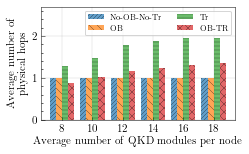

In [12]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances - 1)

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['8', '10', '12', '14', '16', "18", "20"]
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
label_position = [elem + width/2 for elem in label_position]
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n physical hops')
ax1.set_xlabel('Average number of QKD modules per node')
ax1.set_ylim(0, 2.7)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/module-num-physical-hops.pdf')
fig.savefig('plot/module-num-physical-hops.png')

In [13]:
dataMatrix = num_virtual_hops
print(dataMatrix)

[[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.15579607 0.14554252 0.13966487 0.13852802 0.13841349 0.13841349]
 [0.98633329 0.90553046 0.86940753 0.82440803 0.86895225 0.86267271]
 [0.64684875 0.53477226 0.5271689  0.54347672 0.50952375 0.52188815]]


[0.1, 1.1, 2.1, 3.1, 4.1, 5.1]
['8', '10', '12', '14', '16', '18']


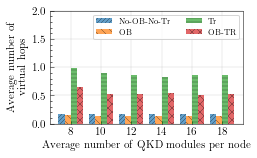

In [15]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances - 1)

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['8', '10', '12', '14', '16', "18", "20"]
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
label_position = [elem + width/2 for elem in label_position]
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n virtual hops')
ax1.set_xlabel('Average number of QKD modules per node')
ax1.set_ylim(0, 2)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/module-num-virtual-hops.pdf')
fig.savefig('plot/module-num-virtual-hops.png')